# Bases

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V01 — "Bases" (DeepLearning.AI).*

A **basis** is a fundamental concept you've quietly used all course — the two vectors defining the unit square (and the parallelogram it maps to) are bases. This video makes the idea precise. We cover:

- What a basis **is**: vectors whose **linear combinations reach every point**.
- Why **almost any** two vectors form a basis of the plane.
- What **fails** to be a basis (vectors on the same line).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. What is a basis?

A matrix-as-transformation sends the fundamental square to a parallelogram — but what really matters isn't the four corners, it's the **two vectors from the origin** that define it. Those two vectors are the **basis**.

> **Defining property:** every point in the space can be written as a **linear combination** of the basis vectors — you can reach any point by walking along the two basis directions (with fractional steps, and backwards allowed).

For basis vectors $b_1, b_2$, reaching a point $p$ means finding weights $c_1, c_2$ with

$$ p = c_1 b_1 + c_2 b_2. $$

In [2]:
# A basis and a target point; find the weights c1, c2 that reach it
b1 = np.array([2, 1])
b2 = np.array([-1, 1])
p  = np.array([3, 3])

# solve [b1 b2] @ c = p  for the coordinates c = (c1, c2)
Bmat = np.column_stack([b1, b2])
c = np.linalg.solve(Bmat, p)
print('weights c1, c2 =', c)
print('check c1*b1 + c2*b2 =', c[0]*b1 + c[1]*b2, ' (= p)')

weights c1, c2 = [2. 1.]
check c1*b1 + c2*b2 = [3. 3.]  (= p)


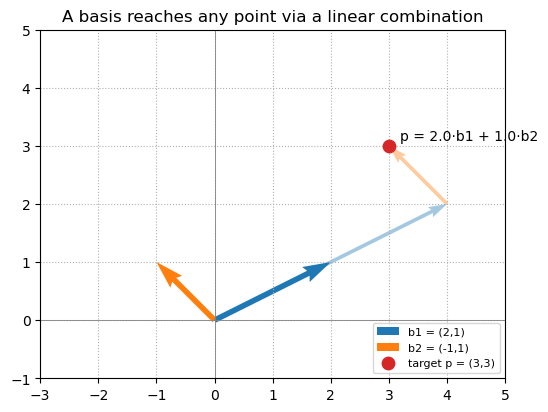

In [3]:
# Visualize: reach p by walking c1 along b1, then c2 along b2
fig, ax = plt.subplots(figsize=(6, 6))
opts = dict(angles='xy', scale_units='xy', scale=1)
ax.quiver(0, 0, *b1, color='C0', width=0.012, **opts, label='b1 = (2,1)')
ax.quiver(0, 0, *b2, color='C1', width=0.012, **opts, label='b2 = (-1,1)')
# path: c1*b1 then c2*b2
step1 = c[0]*b1
ax.quiver(0, 0, *step1, color='C0', alpha=0.4, width=0.008, **opts)
ax.quiver(*step1, *(c[1]*b2), color='C1', alpha=0.4, width=0.008, **opts)
ax.scatter(*p, color='C3', s=80, zorder=5, label='target p = (3,3)')
ax.annotate(f'p = {c[0]:.1f}·b1 + {c[1]:.1f}·b2', p, textcoords='offset points', xytext=(8, 4))
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(-3, 5); ax.set_ylim(-1, 5)
ax.set_title('A basis reaches any point via a linear combination')
plt.show()

## 2. Almost any two vectors form a basis

There's nothing special about the standard axes — **lots** of vector pairs work. As long as the two vectors point in **different directions**, their linear combinations fill the whole plane, so they form a basis. In fact it's *hard* to find two vectors that **don't**.

In [4]:
candidates = {
    'standard  {(1,0),(0,1)}': (np.array([1, 0]), np.array([0, 1])),
    'skewed    {(2,1),(-1,1)}': (np.array([2, 1]), np.array([-1, 1])),
    'another   {(1,2),(3,1)}': (np.array([1, 2]), np.array([3, 1])),
}
for name, (v1, v2) in candidates.items():
    det = np.linalg.det(np.column_stack([v1, v2]))
    print(f'{name}:  det = {det:5.1f}  ->  {"basis" if not np.isclose(det, 0) else "NOT a basis"}')

standard  {(1,0),(0,1)}:  det =   1.0  ->  basis
skewed    {(2,1),(-1,1)}:  det =   3.0  ->  basis
another   {(1,2),(3,1)}:  det =  -5.0  ->  basis


## 3. What is *not* a basis?

If the two vectors lie on the **same line** — pointing the same way *or* exact opposites — their combinations only cover **that line**, never the full plane. Such a pair is **not** a basis.

The algebraic test: two vectors form a basis of the plane $\iff$ they are **not collinear** $\iff$ the matrix with them as columns has **non-zero determinant** (they're *linearly independent*, i.e. non-singular).

In [5]:
b1 = np.array([1, 2])
b2 = np.array([2, 4])     # = 2 * b1  -> same line
det = np.linalg.det(np.column_stack([b1, b2]))
print('b2 = 2*b1, collinear.  det =', det, ' -> NOT a basis (covers only a line)')

# Try to reach an off-line point like (1, 0): the system has no solution
try:
    np.linalg.solve(np.column_stack([b1, b2]), np.array([1, 0]))
except np.linalg.LinAlgError as e:
    print('cannot reach (1,0):', e)

b2 = 2*b1, collinear.  det = 0.0  -> NOT a basis (covers only a line)
cannot reach (1,0): Singular matrix


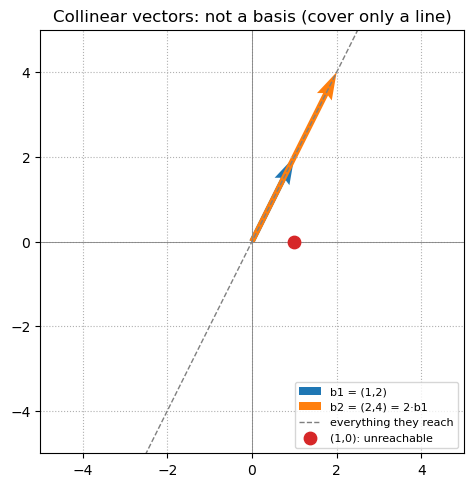

In [6]:
# Visualize: collinear vectors only reach a line
fig, ax = plt.subplots(figsize=(5.5, 5.5))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.013)
ax.quiver(0, 0, *b1, color='C0', **opts, label='b1 = (1,2)')
ax.quiver(0, 0, *b2, color='C1', **opts, label='b2 = (2,4) = 2·b1')
line = np.outer(np.linspace(-3, 3, 2), b1 / np.linalg.norm(b1) * 4)
ax.plot(line[:, 0], line[:, 1], 'C7', ls='--', lw=1, label='everything they reach')
ax.scatter(1, 0, color='C3', s=80, zorder=5, label='(1,0): unreachable')
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_title('Collinear vectors: not a basis (cover only a line)')
plt.show()

## Summary

- A **basis** is a set of vectors whose **linear combinations reach every point** of the space — the two vectors defining the fundamental square are the canonical example.
- Any point $p$ has **coordinates** $(c_1, c_2)$ in a basis: $p = c_1 b_1 + c_2 b_2$ (found by solving a linear system).
- **Almost any** two (non-collinear) vectors form a basis of the plane.
- Vectors on the **same line** are **not** a basis — they only span a line. Test: they form a basis $\iff$ the matrix of columns has **non-zero determinant** (linearly independent / non-singular).